<a href="https://colab.research.google.com/github/miriamamin1213-ux/HPV-classification/blob/main/Copy_of_ModelLR_11F_44.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# LOGISTIC REGRESSION
#
# ============================================================

!pip install -q gdown

import gdown

gdown.download(
    id="1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv",
    output="HPV2025.xlsx",
    quiet=False
)

import os
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    roc_auc_score,
    f1_score
)

from imblearn.over_sampling import SMOTE

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

def seed_everything(seed=44):

    random.seed(seed)
    np.random.seed(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

SEED = 44

seed_everything(SEED)

# ------------------------------------------------------------
# Read Dataset
# ------------------------------------------------------------

df = pd.read_excel("HPV2025.xlsx")

df = df.dropna(subset=["HPV Status"])

tobacco_mode = df["Tobacco Consumption"].mode()[0]

df["Tobacco Consumption"] = df[
    "Tobacco Consumption"
].fillna(tobacco_mode)

alcohol_mode = df["Alcohol Consumption"].mode()[0]

df["Alcohol Consumption"] = df[
    "Alcohol Consumption"
].fillna(alcohol_mode)

df = df.drop(
    columns=[
        "PatientID",
        "CenterID",
        "Task 1",
        "Task 2",
        "Task 3"
    ]
)

df = df.dropna()

print(df.shape)

# ------------------------------------------------------------
# Encode stages
# ------------------------------------------------------------

df["T-stage"] = df["T-stage"].replace({
    "T0":0,
    "T1":1,
    "T2":2,
    "T3":3,
    "T4":4
})

df["N-stage"] = df["N-stage"].replace({
    "N0":0,
    "N1":1,
    "N2":2,
    "N3":3
})

df["M-stage"] = df["M-stage"].replace({
    "M0":0,
    "M1":1
})

# ------------------------------------------------------------
# Features
# ------------------------------------------------------------

X = df[
[
"Age",
"Gender",
"Tobacco Consumption",
"Alcohol Consumption",
"Performance Status",
"Relapse",
"RFS",
"Treatment",
"T-stage",
"N-stage",
"M-stage"
]
]

y = df["HPV Status"]

# ------------------------------------------------------------
# Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=SEED

)

print("\nTrain samples:")

print(y_train.value_counts())

print("\nTest samples:")

print(y_test.value_counts())

# ------------------------------------------------------------
# Standardisation
# ------------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# ------------------------------------------------------------
# SMOTE
# ------------------------------------------------------------

smote = SMOTE(random_state=SEED)

X_train_smote, y_train_smote = smote.fit_resample(

    X_train,
    y_train

)

print("\nAfter SMOTE:")

print(pd.Series(y_train_smote).value_counts())


# ------------------------------------------------------------
# Logistic Regression Model
# ------------------------------------------------------------

model = LogisticRegression(

    random_state=SEED,

    max_iter=1000

)

model.fit(

    X_train_smote,

    y_train_smote

)

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

predicted = model.predict(

    X_test

)

probabilities = model.predict_proba(

    X_test

)[:,1]

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print()

print("Classification Report\n")

print(

    classification_report(

        y_test,

        predicted,

        digits=4

    )

)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(

    y_test,

    predicted

)

print("Confusion Matrix")

print(cm)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

accuracy = (

    (predicted == y_test).sum()

    /

    len(y_test)

)

bal_acc = balanced_accuracy_score(

    y_test,

    predicted

)

f1 = f1_score(

    y_test,

    predicted

)

auc = roc_auc_score(

    y_test,

    probabilities

)

print()

print(f"Accuracy:            {accuracy:.4f}")

print(f"Balanced Accuracy:   {bal_acc:.4f}")

print(f"F1-score:            {f1:.4f}")

print(f"AUC:                 {auc:.4f}")

# ------------------------------------------------------------
# MODEL SUMMARY
# ------------------------------------------------------------

print()

print("====================================")

print("LOGISTIC REGRESSION SUMMARY")

print("====================================")

print("Model : Logistic Regression")

print("Input Features : 11")

print("Learning Rate : N/A")

print("Optimiser : N/A")

print("Class Weights : None")

print("SMOTE : Yes")

print("Training Patients :", len(y_train))

print("Test Patients :", len(y_test))

print("Training after SMOTE :", len(y_train_smote))

print("Seed :", SEED)

print()

print("Final Results")

print("---------------------------")

print(f"Accuracy            : {accuracy:.4f}")

print(f"Balanced Accuracy   : {bal_acc:.4f}")

print(f"F1-score            : {f1:.4f}")

print(f"AUC                 : {auc:.4f}")

print()

print("Confusion Matrix")

print(cm)

print()

print("Analysis Complete.")

Downloading...
From: https://drive.google.com/uc?id=1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv
To: /content/HPV2025.xlsx
100%|██████████| 66.0k/66.0k [00:00<00:00, 12.0MB/s]


(423, 12)

Train samples:
HPV Status
1.0    318
0.0     20
Name: count, dtype: int64

Test samples:
HPV Status
1.0    82
0.0     3
Name: count, dtype: int64

After SMOTE:
HPV Status
1.0    318
0.0    318
Name: count, dtype: int64

Classification Report

              precision    recall  f1-score   support

         0.0     0.1765    1.0000    0.3000         3
         1.0     1.0000    0.8293    0.9067        82

    accuracy                         0.8353        85
   macro avg     0.5882    0.9146    0.6033        85
weighted avg     0.9709    0.8353    0.8853        85

Confusion Matrix
[[ 3  0]
 [14 68]]

Accuracy:            0.8353
Balanced Accuracy:   0.9146
F1-score:            0.9067
AUC:                 0.8780

LOGISTIC REGRESSION SUMMARY
Model : Logistic Regression
Input Features : 11
Learning Rate : N/A
Optimiser : N/A
Class Weights : None
SMOTE : Yes
Training Patients : 338
Test Patients : 85
Training after SMOTE : 636
Seed : 44

Final Results
---------------------------
A

/tmp/ipykernel_1645/1695572031.py:88: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["T-stage"] = df["T-stage"].replace({
/tmp/ipykernel_1645/1695572031.py:96: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["N-stage"] = df["N-stage"].replace({
/tmp/ipykernel_1645/1695572031.py:103: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_s

In [2]:
# ============================================================
# LIME ANALYSIS
# LOGISTIC REGRESSION
# SEED 44
# ============================================================

!pip install -q lime

import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np

print("Preparing LIME...")

feature_names = [

    "Age",
    "Gender",
    "Tobacco Consumption",
    "Alcohol Consumption",
    "Performance Status",
    "Relapse",
    "RFS",
    "Treatment",
    "T-stage",
    "N-stage",
    "M-stage"

]

class_names = [

    "HPV Negative",
    "HPV Positive"

]

explainer = lime.lime_tabular.LimeTabularExplainer(

    training_data=X_train_smote,

    feature_names=feature_names,

    class_names=class_names,

    mode="classification",

    discretize_continuous=True,

    random_state=44

)

print()

print("LIME Explainer Created Successfully")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Preparing LIME...

LIME Explainer Created Successfully


In [3]:
# ============================================================
# Explain One Patient
# ============================================================

patient = 0

exp = explainer.explain_instance(

    X_test[patient],

    model.predict_proba,

    num_features=11

)

prediction = model.predict(

    X_test[patient].reshape(1,-1)

)[0]

actual = y_test.iloc[patient]

print()

print("Actual Class    :", int(actual))

print("Predicted Class :", int(prediction))

print()

print("LIME Feature Contributions\n")

for feature, weight in exp.as_list():

    print(f"{feature:<45} {weight:.4f}")


Actual Class    : 1
Predicted Class : 1

LIME Feature Contributions

RFS > 0.07                                    0.3550
M-stage <= -0.08                              -0.2969
Tobacco Consumption <= -0.88                  0.2709
T-stage <= -0.12                              0.2536
N-stage <= -1.14                              -0.1382
Relapse <= -0.50                              -0.0489
Age <= -0.52                                  0.0354
-0.85 < Performance Status <= 0.51            0.0187
-1.27 < Alcohol Consumption <= 0.79           0.0045
Gender <= 0.35                                0.0000
Treatment <= 0.48                             0.0000


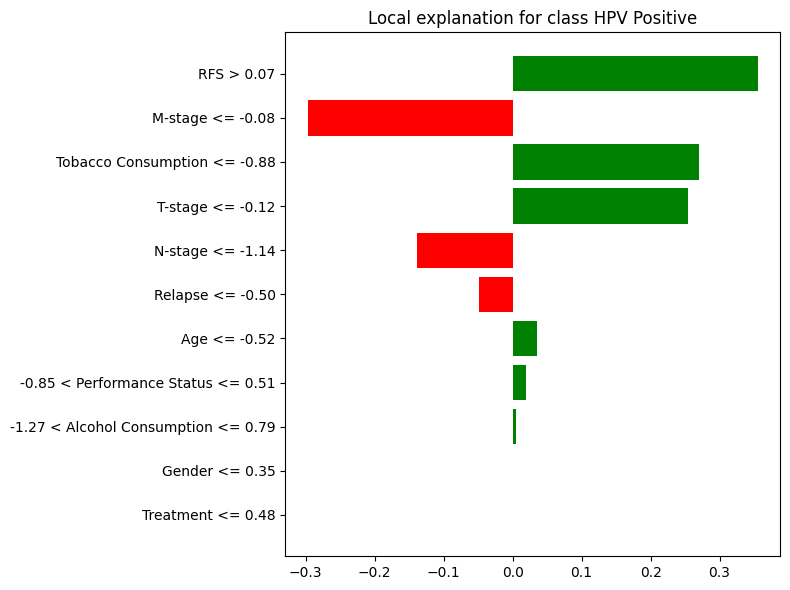


LIME ANALYSIS COMPLETE
Model : Logistic Regression
Seed : 44
Patient Explained : 0

Generated Files
----------------------------
LIME_LogisticRegression_Seed44.png
LIME_LogisticRegression_Seed44.html

Analysis Complete.


In [4]:
# ============================================================
# Save LIME Figure
# ============================================================

fig = exp.as_pyplot_figure()

fig.set_size_inches(8,6)

plt.tight_layout()

plt.savefig(

    "LIME_LogisticRegression_Seed44.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

# ============================================================
# Save HTML Explanation
# ============================================================

exp.save_to_file(

    "LIME_LogisticRegression_Seed44.html"

)

print()

print("====================================")

print("LIME ANALYSIS COMPLETE")

print("====================================")

print("Model : Logistic Regression")

print("Seed : 44")

print("Patient Explained :", patient)

print()

print("Generated Files")

print("----------------------------")

print("LIME_LogisticRegression_Seed44.png")

print("LIME_LogisticRegression_Seed44.html")

print()

print("Analysis Complete.")

In [5]:
# ============================================================
# SHAP ANALYSIS
# LOGISTIC REGRESSION
# LINEAR SHAP
# SEED 44
# ============================================================

!pip install -q shap

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Preparing SHAP...")

feature_names = [

    "Age",
    "Gender",
    "Tobacco Consumption",
    "Alcohol Consumption",
    "Performance Status",
    "Relapse",
    "RFS",
    "Treatment",
    "T-stage",
    "N-stage",
    "M-stage"

]

print("Training Shape :", X_train_smote.shape)
print("Test Shape     :", X_test.shape)

# ------------------------------------------------------------
# Create Linear SHAP Explainer
# ------------------------------------------------------------

explainer = shap.LinearExplainer(

    model,

    X_train_smote

)

print()

print("Linear SHAP Explainer Created Successfully")

Preparing SHAP...
Training Shape : (636, 11)
Test Shape     : (85, 11)

Linear SHAP Explainer Created Successfully


In [6]:
# ============================================================
# Calculate SHAP Values
# ============================================================

print()

print("Calculating SHAP values...")

shap_values = explainer.shap_values(

    X_test

)

print("Done!")

print()

print("SHAP Shape :", np.array(shap_values).shape)

# ============================================================
# SHAP Summary Plot
# ============================================================

print()

print("Generating SHAP Summary Plot...")

plt.figure(figsize=(10,6))

shap.summary_plot(

    shap_values,

    X_test,

    feature_names=feature_names,

    show=False

)

plt.tight_layout()

plt.savefig(

    "SHAP_Summary_LogisticRegression_Seed44.png",

    dpi=300,

    bbox_inches="tight"

)

plt.close()

# ============================================================
# SHAP Bar Plot
# ============================================================

print()

print("Generating SHAP Bar Plot...")

plt.figure(figsize=(8,6))

shap.summary_plot(

    shap_values,

    X_test,

    feature_names=feature_names,

    plot_type="bar",

    show=False

)

plt.tight_layout()

plt.savefig(

    "SHAP_Bar_LogisticRegression_Seed44.png",

    dpi=300,

    bbox_inches="tight"

)

plt.close()

print()

print("Saved:")

print("SHAP_Summary_LogisticRegression_Seed44.png")

print("SHAP_Bar_LogisticRegression_Seed44.png")


Calculating SHAP values...
Done!

SHAP Shape : (85, 11)

Generating SHAP Summary Plot...


/tmp/ipykernel_1645/3808852820.py:31: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(



Generating SHAP Bar Plot...


/tmp/ipykernel_1645/3808852820.py:67: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(



Saved:
SHAP_Summary_LogisticRegression_Seed44.png
SHAP_Bar_LogisticRegression_Seed44.png


In [7]:
# ============================================================
# Create SHAP Feature Importance
# ============================================================

print()

print("Creating SHAP Feature Importance...")

mean_shap = np.abs(shap_values).mean(axis=0)

importance = pd.DataFrame({

    "Feature": feature_names,

    "Mean Absolute SHAP Value": mean_shap

})

importance = importance.sort_values(

    by="Mean Absolute SHAP Value",

    ascending=False

)

importance.to_csv(

    "SHAP_Feature_Importance_LogisticRegression_Seed44.csv",

    index=False

)

print()

print("GLOBAL SHAP FEATURE IMPORTANCE")

print("--------------------------------")

print(importance)

print()

print("Top 11 SHAP Features")

print("------------------------------")

for i, row in enumerate(importance.itertuples(index=False), start=1):

    print(

        f"{i:>2}. "

        f"{row.Feature:<28}"

        f"{row[1]:.6f}"

    )

# ============================================================
# Save Predictions
# ============================================================

prediction_df = pd.DataFrame({

    "Actual": y_test,

    "Predicted": predicted,

    "Probability HPV Positive": probabilities

})

prediction_df.to_csv(

    "SHAP_Predictions_LogisticRegression_Seed44.csv",

    index=False

)

print()

print("====================================")

print("SHAP ANALYSIS COMPLETE")

print("====================================")

print("Model : Logistic Regression")

print("Explainer : Linear SHAP")

print("Seed : 44")

print("Patients Explained :", len(X_test))

print("Features :", len(feature_names))

print()

print("Generated Files")

print("----------------------------")

print("SHAP_Summary_LogisticRegression_Seed44.png")

print("SHAP_Bar_LogisticRegression_Seed44.png")

print("SHAP_Feature_Importance_LogisticRegression_Seed44.csv")

print("SHAP_Predictions_LogisticRegression_Seed44.csv")

print()

print("Analysis Complete.")


Creating SHAP Feature Importance...

GLOBAL SHAP FEATURE IMPORTANCE
--------------------------------
                Feature  Mean Absolute SHAP Value
2   Tobacco Consumption                  2.248937
6                   RFS                  1.389008
8               T-stage                  0.973927
7             Treatment                  0.488900
4    Performance Status                  0.461754
9               N-stage                  0.422238
1                Gender                  0.299501
5               Relapse                  0.266248
0                   Age                  0.128622
10              M-stage                  0.042094
3   Alcohol Consumption                  0.017101

Top 11 SHAP Features
------------------------------
 1. Tobacco Consumption         2.248937
 2. RFS                         1.389008
 3. T-stage                     0.973927
 4. Treatment                   0.488900
 5. Performance Status          0.461754
 6. N-stage                     0.422238

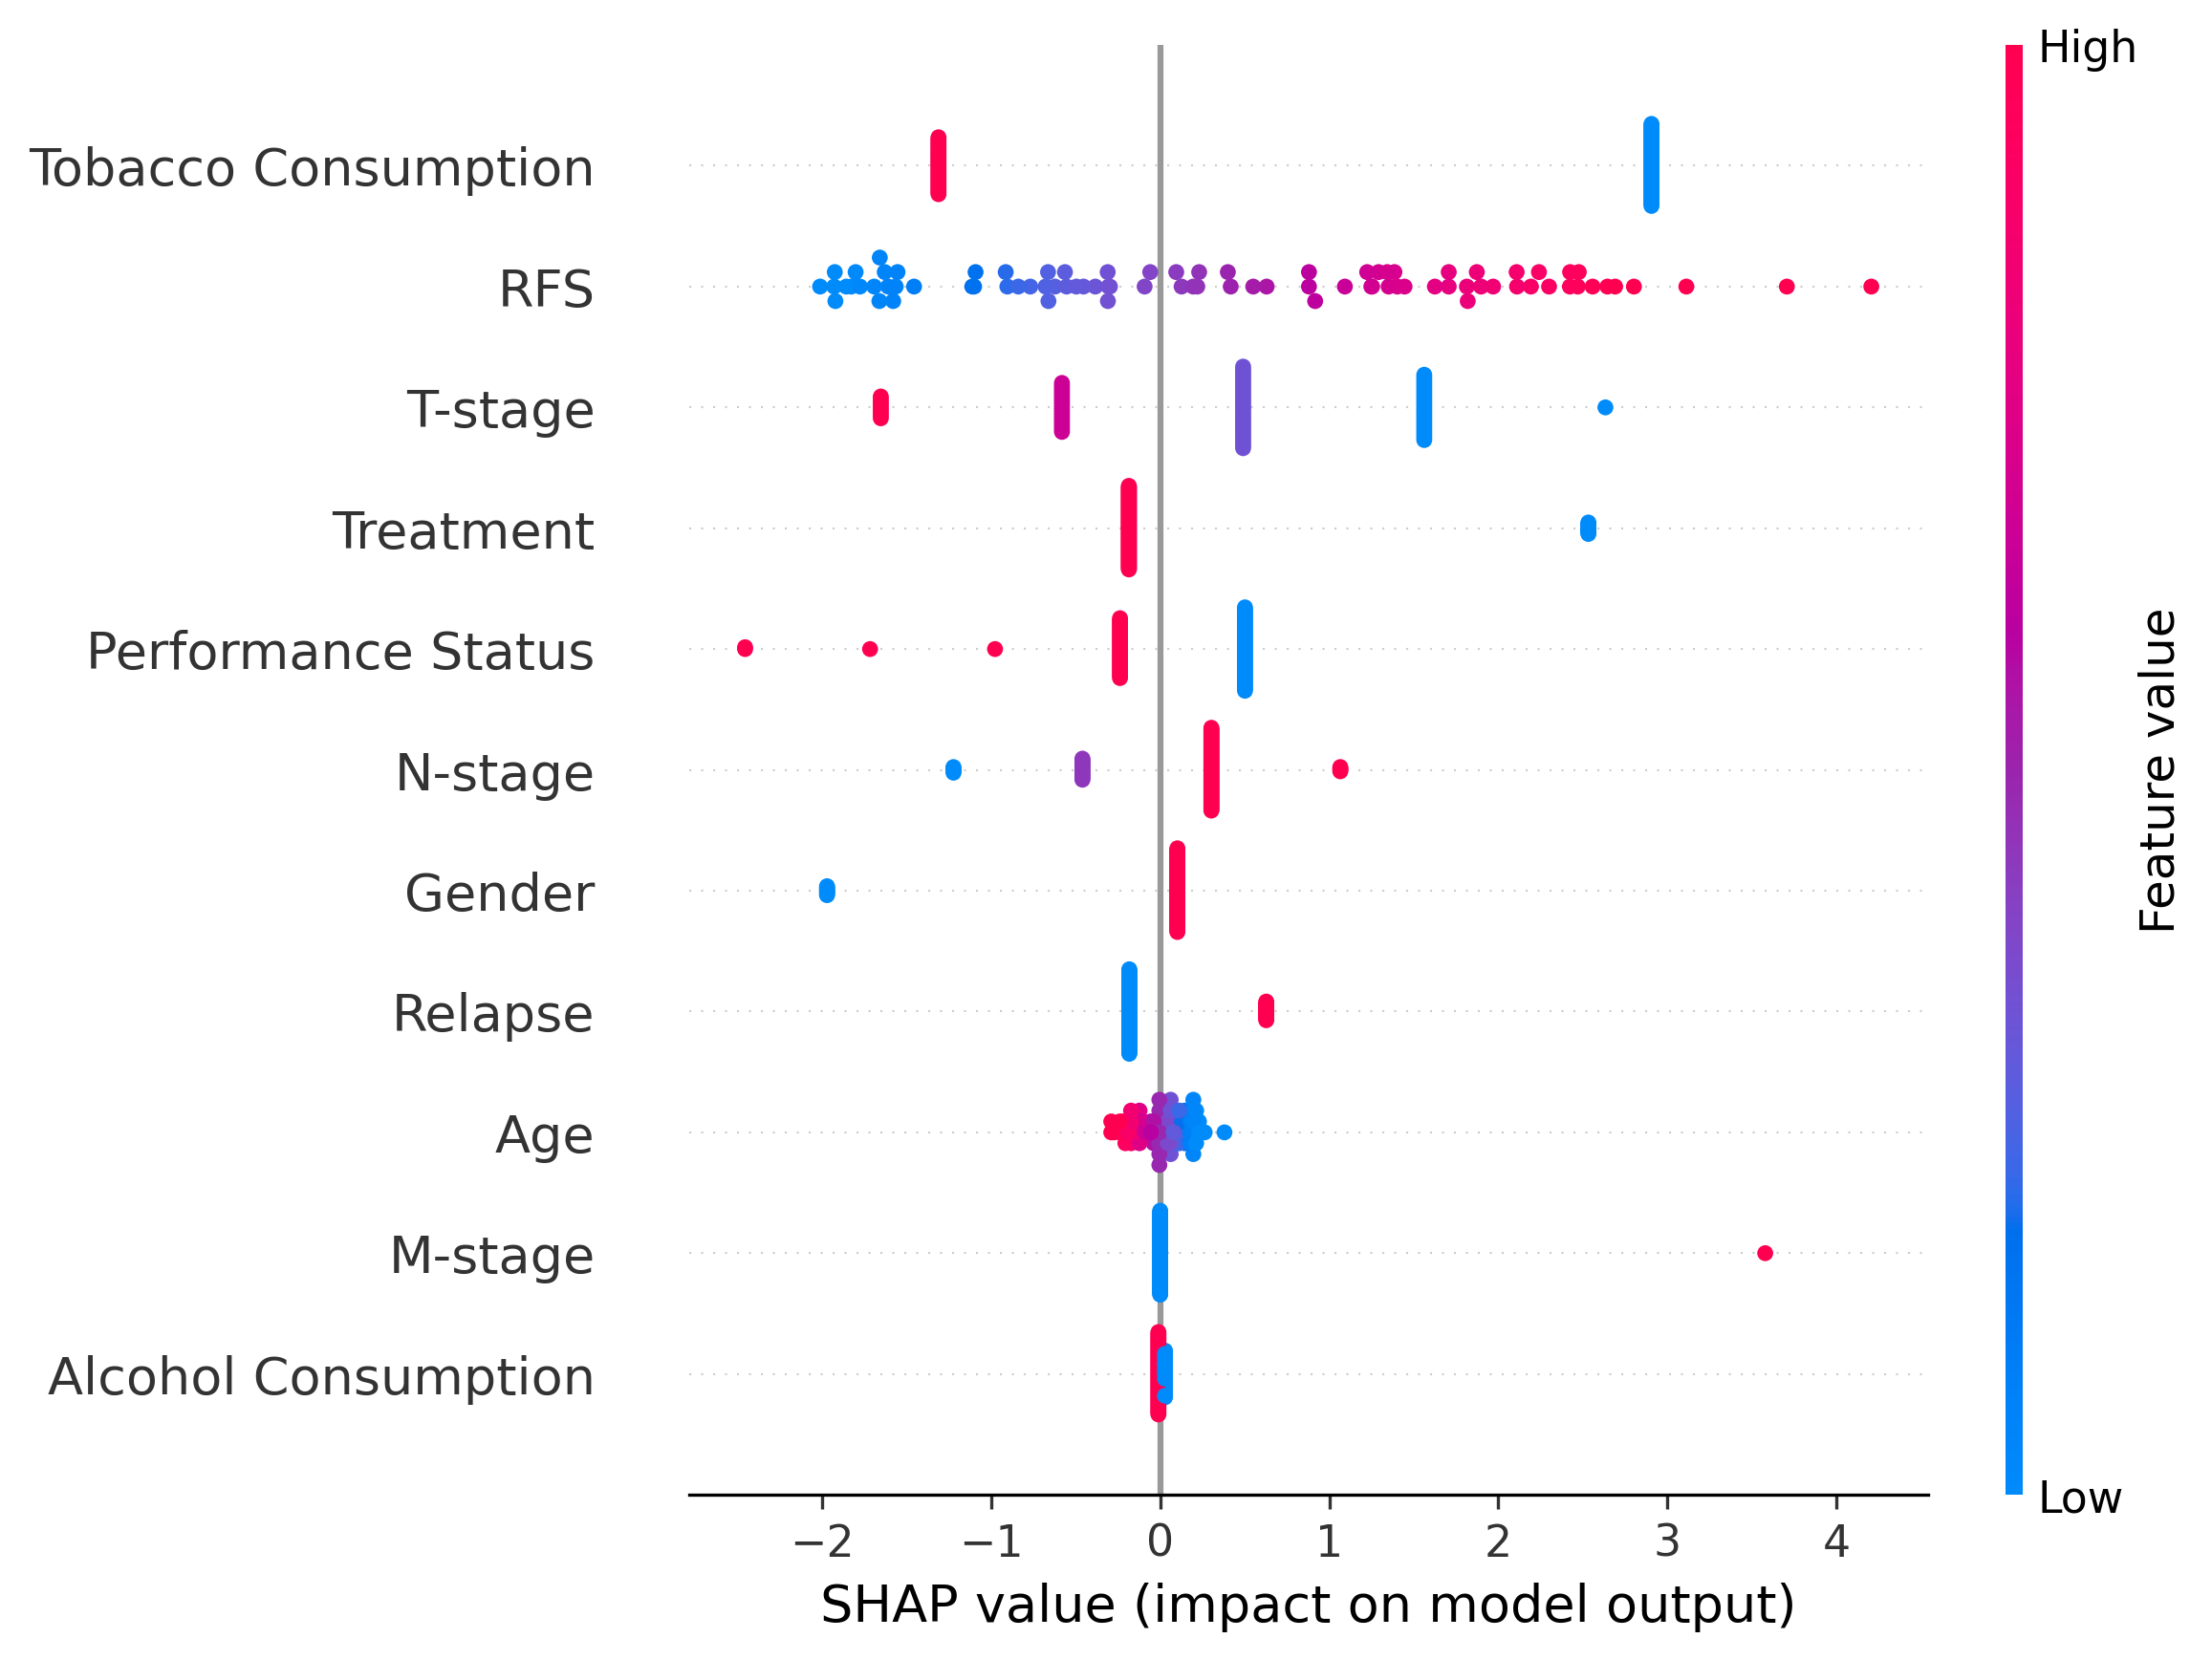

In [8]:
from IPython.display import Image, display

display(Image("SHAP_Summary_LogisticRegression_Seed44.png"))

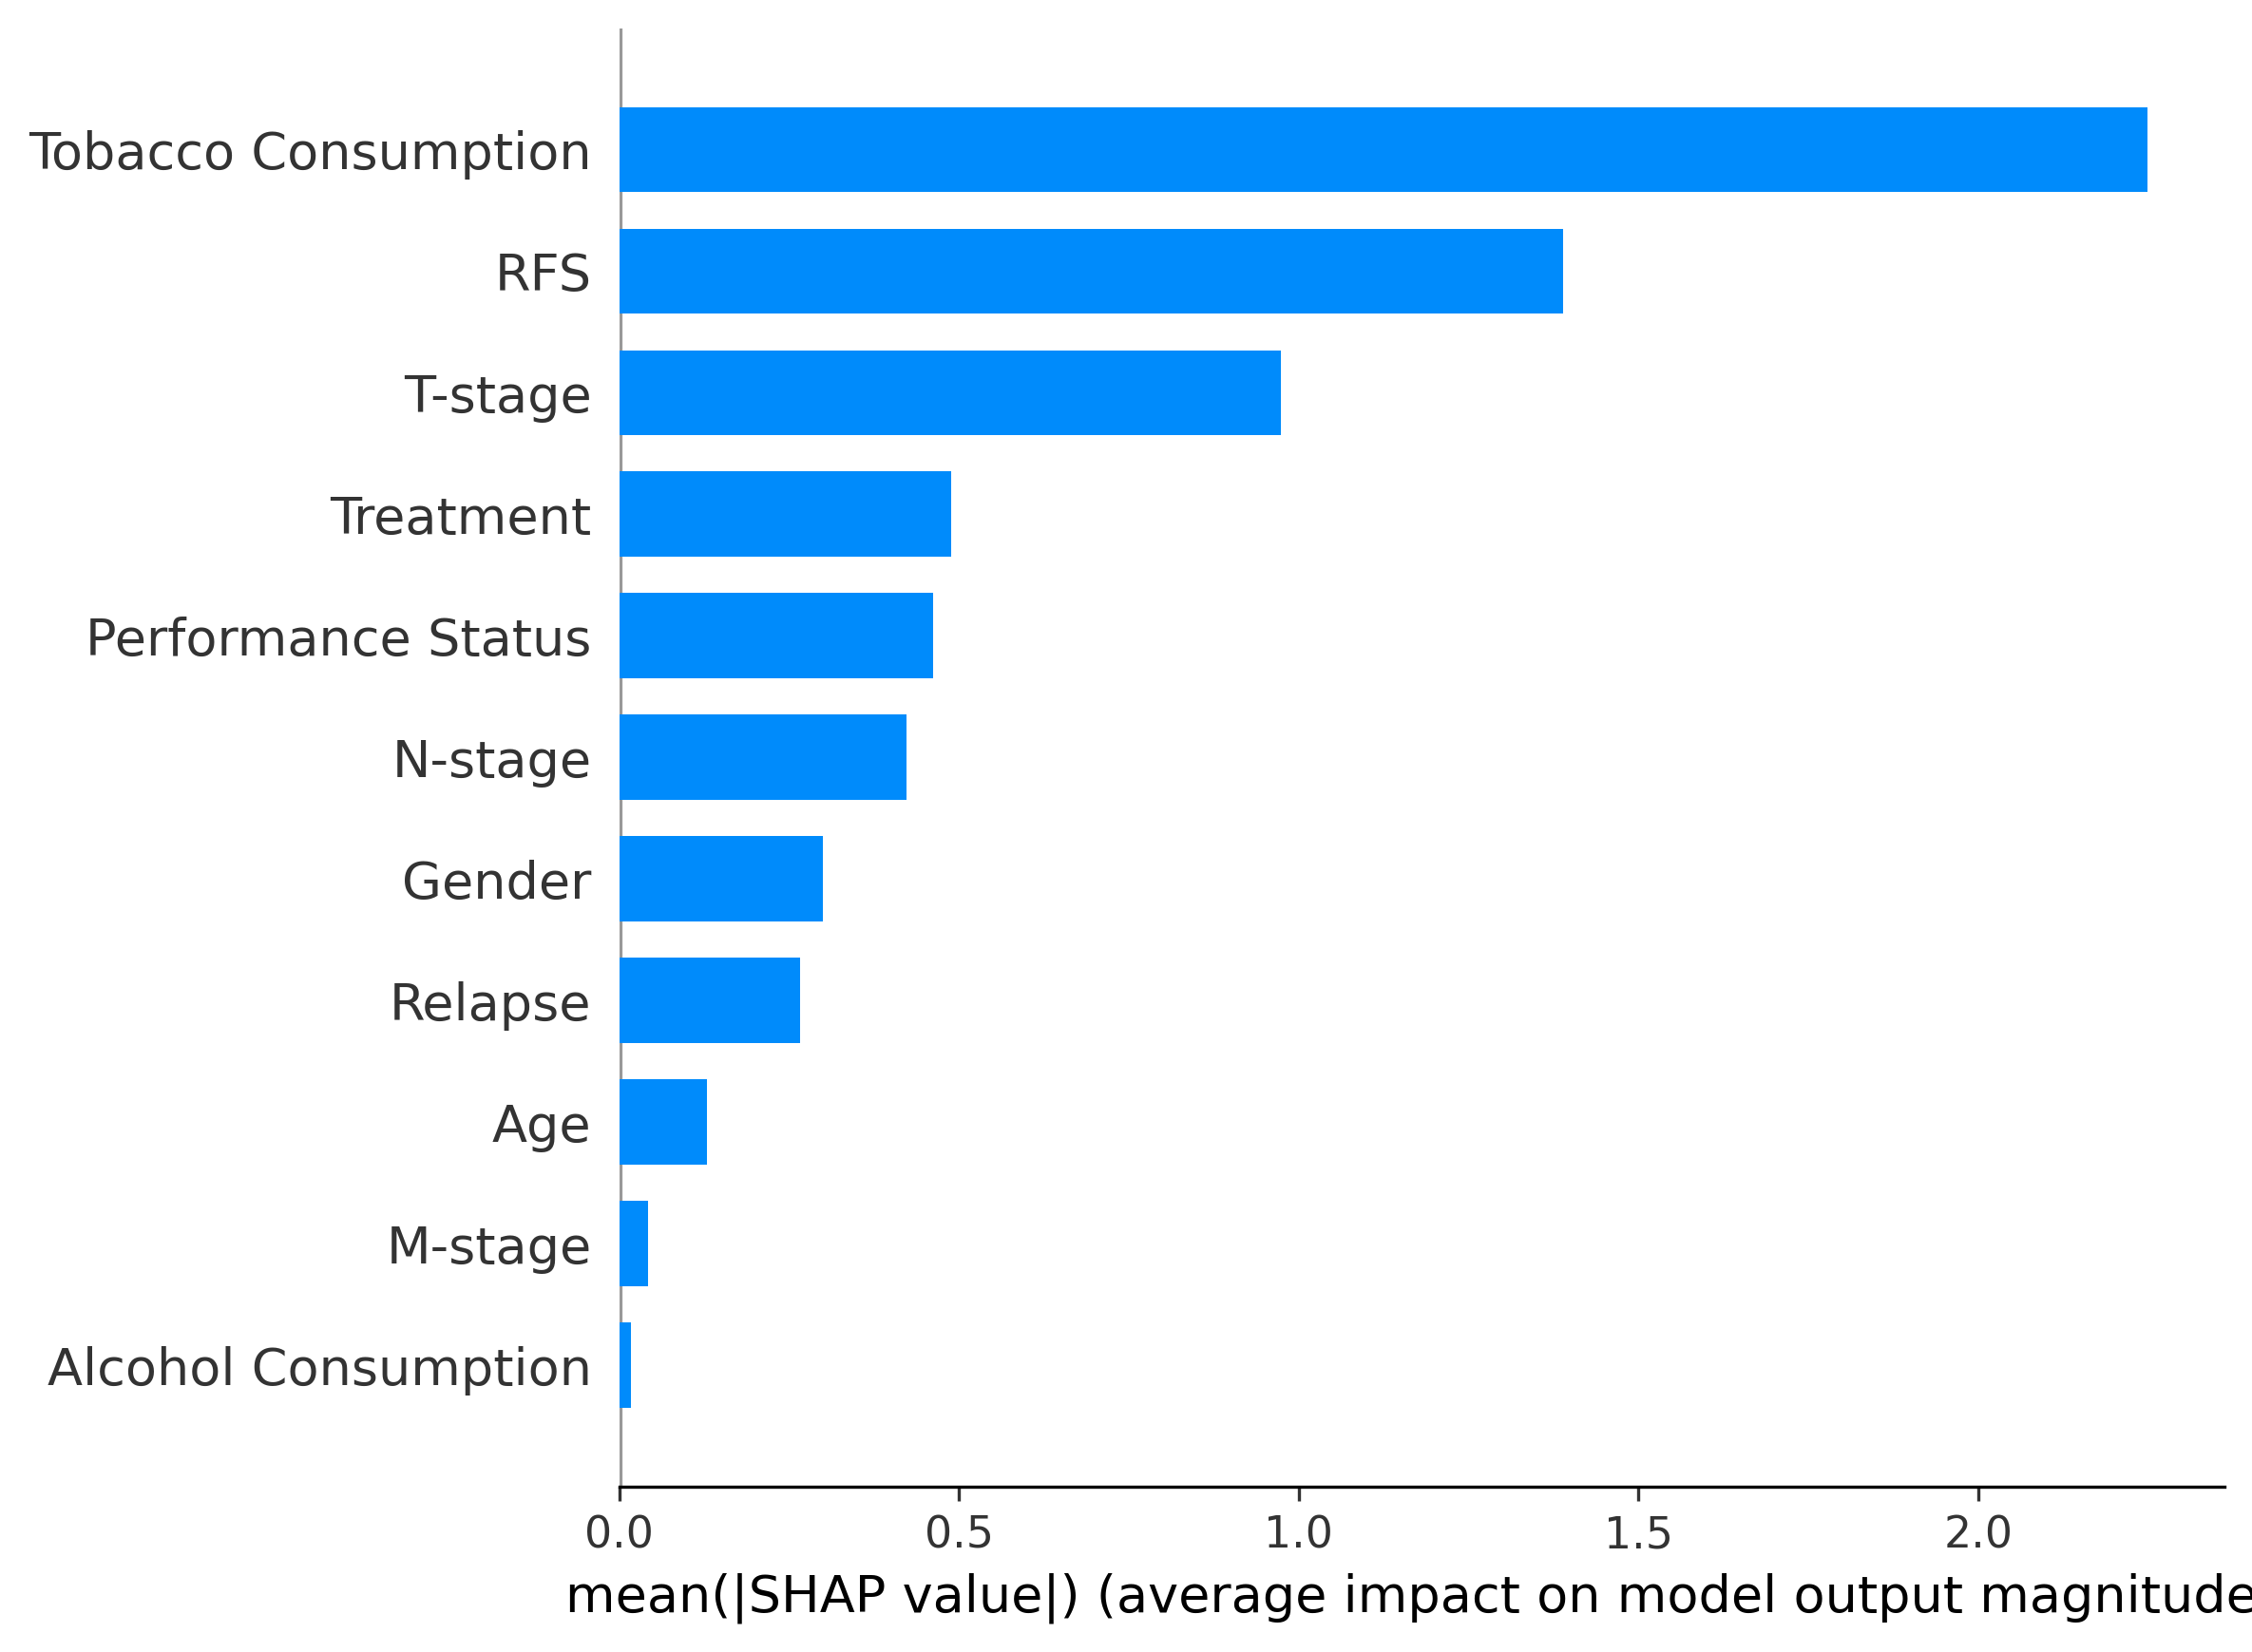

In [9]:
from IPython.display import Image, display

display(Image("SHAP_Bar_LogisticRegression_Seed44.png"))

/tmp/ipykernel_1645/3808224464.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


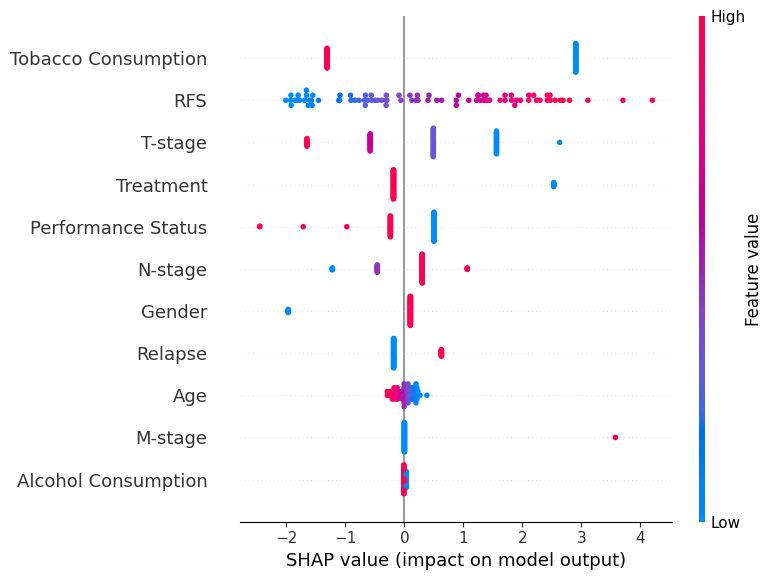

In [10]:
plt.figure(figsize=(8,5))

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.savefig(
    "SHAP_Summary_LogisticRegression_Seed44.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

/tmp/ipykernel_1645/2899065893.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


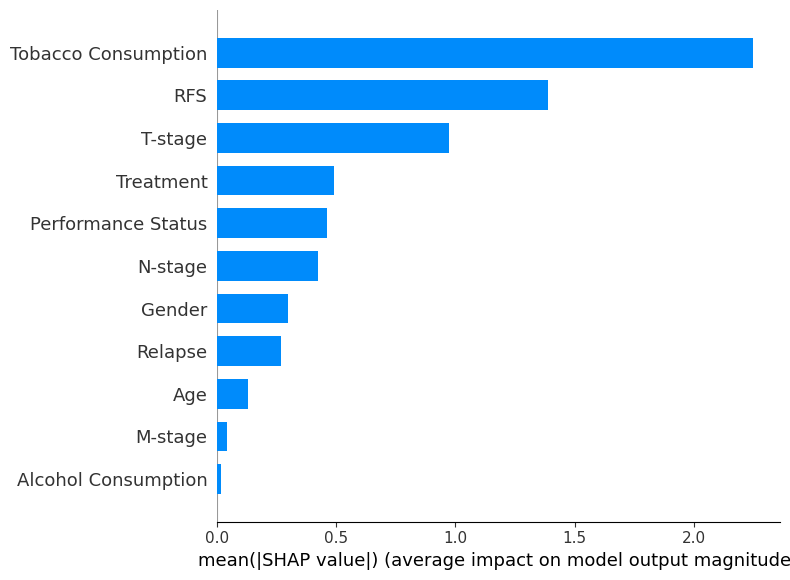

In [11]:
plt.figure(figsize=(6,5))

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig(
    "SHAP_Bar_LogisticRegression_Seed44.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()